In [1]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [3]:
import os
print(os.listdir())

['.config', 'heart.csv', '.ipynb_checkpoints', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Overview

In [7]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Cleaning and Preprocessing

In [11]:

df.duplicated().sum()


np.int64(0)

In [12]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Missing value analysis was performed on all features in the dataset. No missing values were found in any column. Therefore, no imputation or missing value treatment was required before model training.

##Removing duplicates


In [10]:
df = df.drop_duplicates()

In [13]:
df.shape


(302, 14)

The dataset initially contained 1025 records. During preprocessing, 723 duplicate records were identified and removed. After removing duplicates, the dataset contained 302 unique patient records and 14 features, making it more suitable for unbiased machine learning model training.

## Exploratory Data Analysis (EDA)

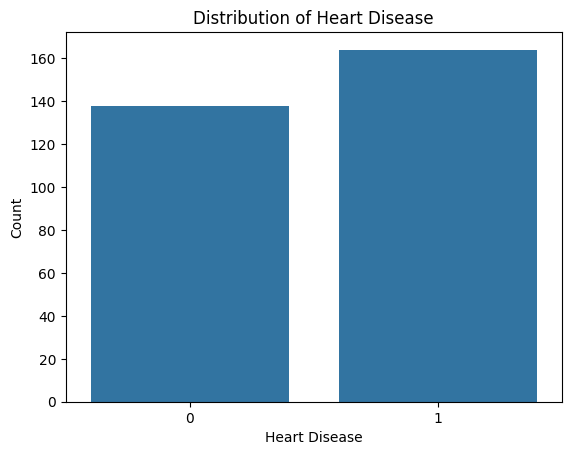

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)

plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

plt.show()

The target variable distribution shows that patients with heart disease (Target = 1) are slightly more frequent than patients without heart disease (Target = 0). The class distribution is relatively balanced, indicating that machine learning models are unlikely to suffer from severe class imbalance issues.

### Age Distribution

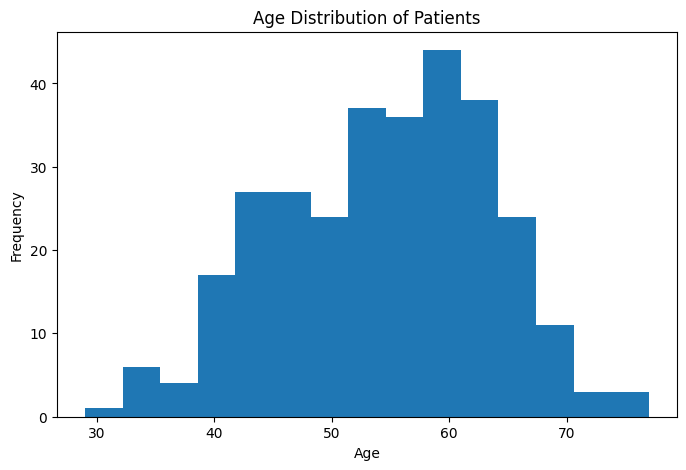

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=15)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

The age distribution indicates that most patients fall within the 50–60 years age group. This suggests that middle-aged individuals are more frequently represented in the dataset. Since heart disease risk generally increases with age due to lifestyle factors and underlying health conditions, this age group may benefit from regular health monitoring and preventive care.

### Gender Distribution

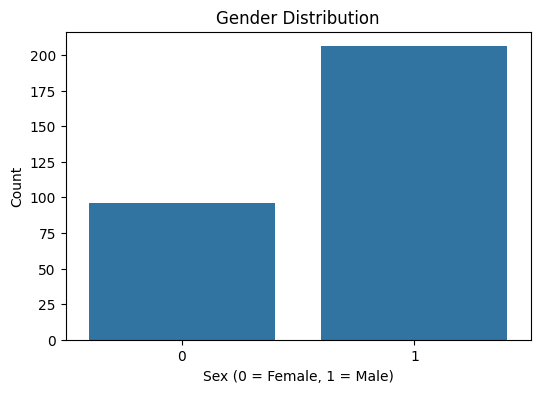

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title('Gender Distribution')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')

plt.show()

The gender distribution analysis shows that male patients are more frequently represented than female patients. The dataset exhibits gender imbalance, with males accounting for a larger proportion of records. This imbalance should be considered when interpreting model results, as the model may learn more strongly from male patient patterns.

### Chest Pain Type Analysis

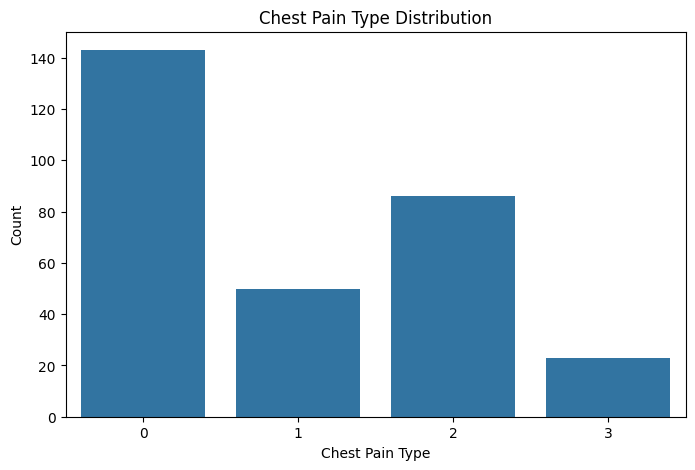

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='cp', data=df)

plt.title('Chest Pain Type Distribution')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

plt.show()

The analysis shows that Chest Pain Type 0 is the most common category, while Type 3 is the least common. Chest pain is an important clinical feature because different pain patterns may be associated with varying levels of cardiovascular risk. Therefore, this feature is expected to contribute significantly to heart disease prediction.

## Cholesterol Distribution

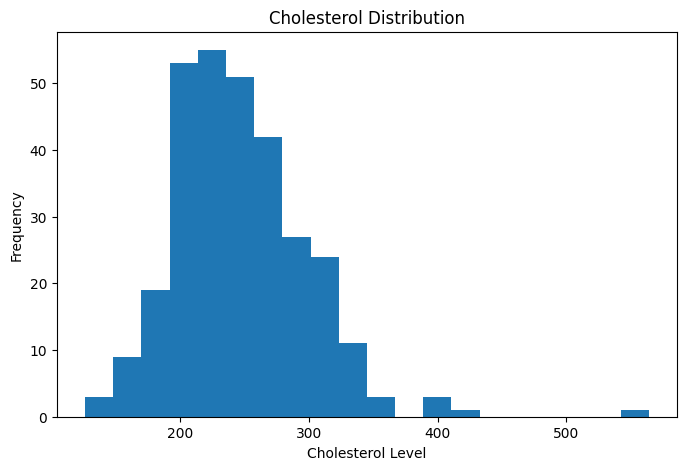

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['chol'], bins=20)

plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol Level')
plt.ylabel('Frequency')

plt.show()

The cholesterol distribution is positively skewed, with most patients having cholesterol levels between 200 and 300. A few observations show unusually high cholesterol values, indicating potential outliers. Since cholesterol is a known cardiovascular risk factor, it is expected to play an important role in predicting heart disease

### Correlation Heatmap

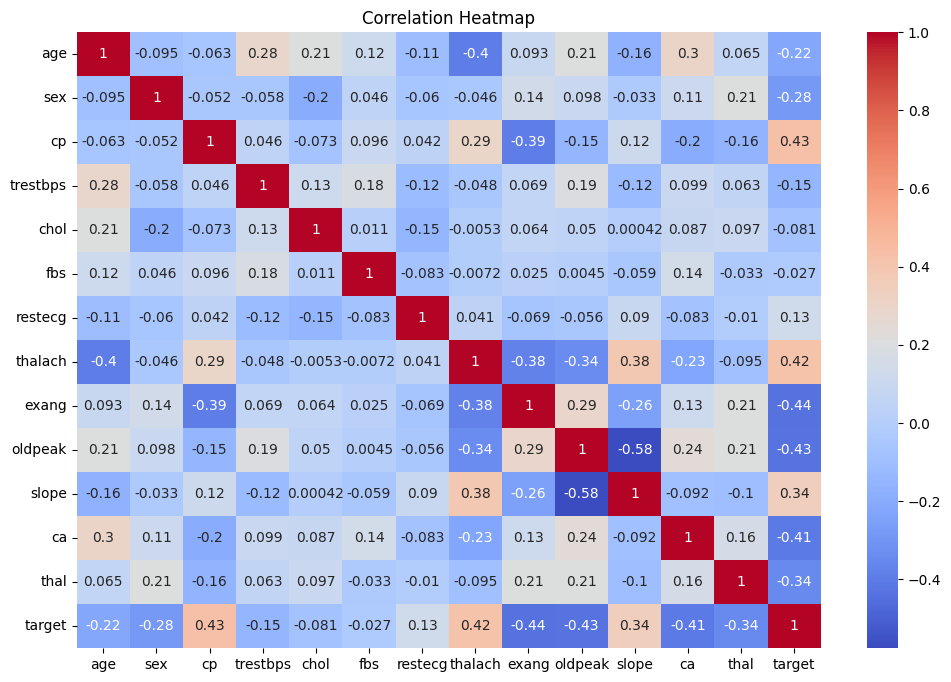

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [20]:
X = df.drop('target', axis=1)

y = df['target']

print(X.shape)
print(y.shape)

(302, 13)
(302,)


##Train-Test

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


The dataset was split into training and testing sets using an 80:20 ratio. The training set contains 241 records and is used for model learning, while the testing set contains 61 records and is used to evaluate model performance on unseen data

## Model 1: Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(lr_pred[:10])

[1 1 0 1 1 0 0 1 1 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, lr_pred)

0.7868852459016393

## Model 2: Random Forest Classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8360655737704918


Random Forest achieved an accuracy of 83.61%, outperforming Logistic Regression. This suggests that the dataset contains non-linear relationships that are better captured by an ensemble tree-based model

## Model 3: K-Nearest Neighbors (KNN)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.639344262295082


KNN is a distance-based algorithm and is sensitive to feature scaling. Since the dataset contains features with different ranges, the model may not have identified nearest neighbors effectively. Random Forest, being a tree-based ensemble model, is less affected by feature scaling and was able to capture complex feature relationships more effectively.

## Model Evaluation and Comparison

In [27]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.786885
1,Random Forest,0.836066
2,KNN,0.639344


Random Forest outperformed the other models because it can capture complex and non-linear relationships between features. It uses multiple decision trees and combines their predictions, making it more robust and accurate than Logistic Regression and KNN for this dataset.

##Confusion Matrix

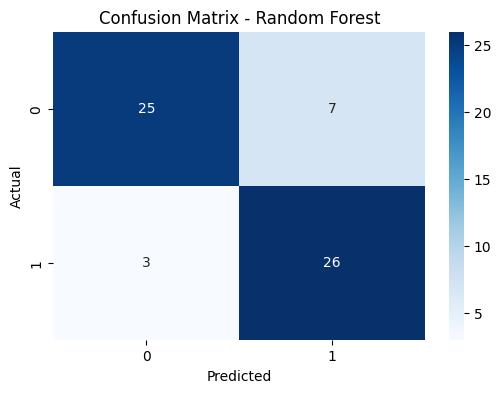

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

##Key Findings

The dataset initially contained 1025 records, out of which 723 duplicate records were removed.

No missing values were found in the dataset.

Most patients belonged to the 50–60 age group.

Male patients were more represented than female patients.

Chest pain type showed the strongest positive correlation with heart disease.

Exercise-induced angina showed the strongest negative correlation with heart disease.

Random Forest achieved the highest predictive performance among all tested models.